# Fraud Anomaly Classification

Exploratory Data Analysis which is focused on spending pattern, transaction frequency and location preference

# 1. Import Libraries

In [23]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import seaborn as sns
from IPython.display import clear_output
from plotly.subplots import make_subplots

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

FIGURES_DIR = Path('..') / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# 2. Load Dataset

In [24]:
df = pd.read_csv('../data/raw/data_100k.csv')
print('Shape:', df.shape)
df.head()

Shape: (100000, 44)


,ssn,cc_num,first,last,gender,street,city,state,zip,lat,...,customer_avg_amout_1_day,customer_avg_amount_7_day,customer_avg_amount_30_day,merchant_num_trans_1_day,merchant_num_trans_7_day,merchant_num_trans_30_day,merchant_risk_1_day,merchant_risk_7_day,merchant_risk_30_day,merchant_risk_90_day
0,351-62-6305,2257691741690970,Crystal,Brady,F,67524 Humphrey Rue Apt. 797,Blairsville,GA,30512,34.8763,...,18.40,41.50,35.55,300.98,42430.81,354481.26,4,10,21,15
1,744-12-3595,2254615782872323,Sharon,Lopez,F,4038 Rachel Prairie,Fresno,CA,93702,36.7400,...,61.23,82.44,66.37,2009.39,22972.95,810182.94,6,11,13,44
2,412-54-7241,375383735799873,Megan,Kidd,F,6893 Andrea Vista,Griffin,GA,30224,33.2404,...,37.24,34.95,38.65,2189.89,57324.21,904398.66,5,6,22,16
3,619-63-8837,180014749433655,Nicholas,Harris,M,659 Hubbard Hollow Apt. 420,Detroit,MI,48238,42.3959,...,61.32,24.86,42.28,2551.60,76989.46,829314.79,7,12,18,49
4,757-72-1212,676335741234,Amy,Bolton,F,0733 Charles Roads Apt. 872,Muscatine,IA,52761,41.4304,...,45.20,15.86,62.12,2145.80,64691.00,855431.87,1,6,7,36


# 3. Data Overview

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 44 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   ssn                         100000 non-null  object 
 1   cc_num                      100000 non-null  int64  
 2   first                       100000 non-null  object 
 3   last                        100000 non-null  object 
 4   gender                      100000 non-null  object 
 5   street                      100000 non-null  object 
 6   city                        100000 non-null  object 
 7   state                       100000 non-null  object 
 8   zip                         100000 non-null  int64  
 9   lat                         100000 non-null  float64
 10  long                        100000 non-null  float64
 11  city_pop                    100000 non-null  int64  
 12  job                         100000 non-null  object 
 13  dob            

In [26]:
# Class balance
print(df['is_fraud'].value_counts())
print('\nFraud rate:', round(df['is_fraud'].mean() * 100, 3), '%')

is_fraud
0    98891
1     1109
Name: count, dtype: int64

Fraud rate: 1.109 %


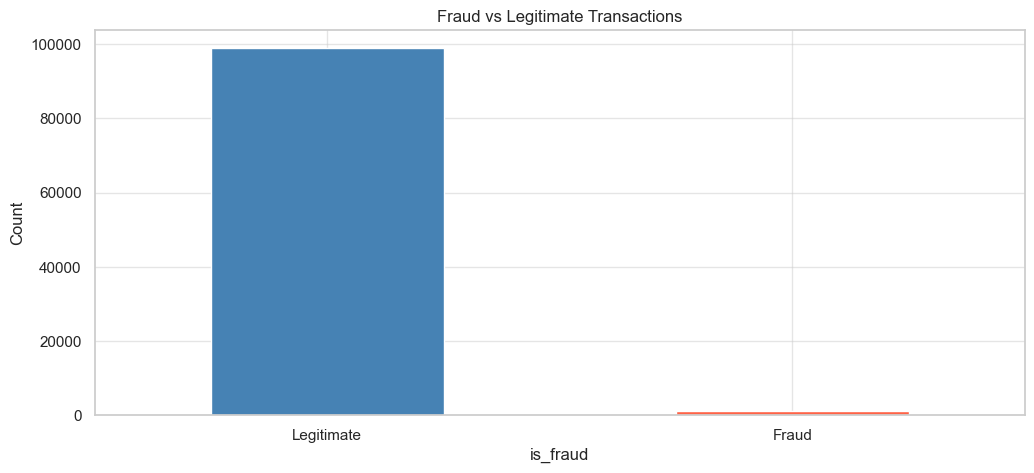

In [27]:
df['is_fraud'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='white')
plt.title('Fraud vs Legitimate Transactions')
plt.xticks([0, 1], ['Legitimate', 'Fraud'], rotation=0)
plt.ylabel('Count')
plt.savefig(FIGURES_DIR / 'class_balance.png', bbox_inches='tight', dpi=150)
plt.show()

# 4. Spending Pattern Analysis

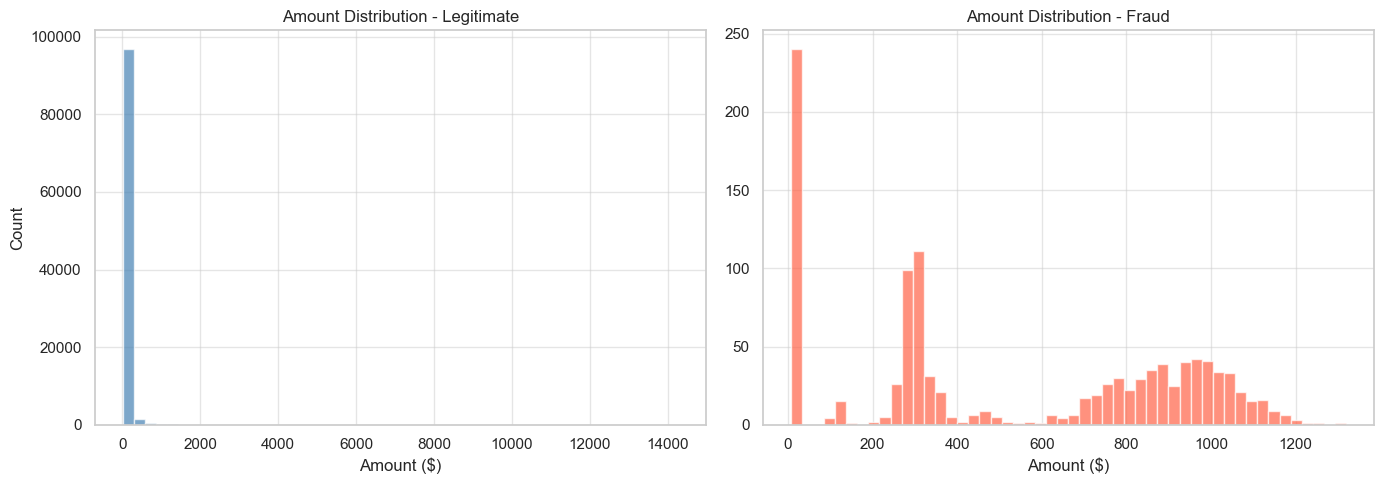

In [28]:
# Amount distribution - fraud vs legit
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[df['is_fraud'] == 0]['amt'], bins=50, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].set_title('Amount Distribution - Legitimate')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Count')

axes[1].hist(df[df['is_fraud'] == 1]['amt'], bins=50, color='tomato', alpha=0.7, edgecolor='white')
axes[1].set_title('Amount Distribution - Fraud')
axes[1].set_xlabel('Amount ($)')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'amount_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

In [29]:
# Compare average spend - fraud vs legit
df.groupby('is_fraud')['amt'].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,98891.0,67.792055,147.247473,1.00,9.16,44.66,81.09,14275.64
1,1109.0,529.653183,392.639194,6.02,257.61,373.67,913.23,1319.82


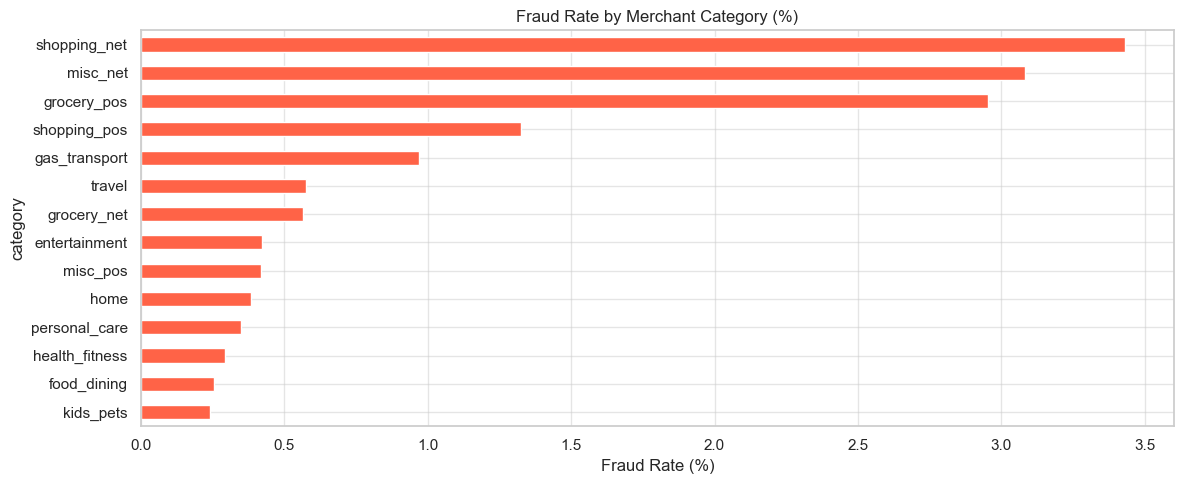

In [30]:
# Fraud rate by merchant category
merch_fraud = df.groupby('category')['is_fraud'].mean().sort_values(ascending=False) * 100
merch_fraud.plot(kind='barh', color='tomato', edgecolor='white')
plt.title('Fraud Rate by Merchant Category (%)')
plt.xlabel('Fraud Rate (%)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fraud_rate_by_merchant_category.png', bbox_inches='tight', dpi=150)
plt.show()

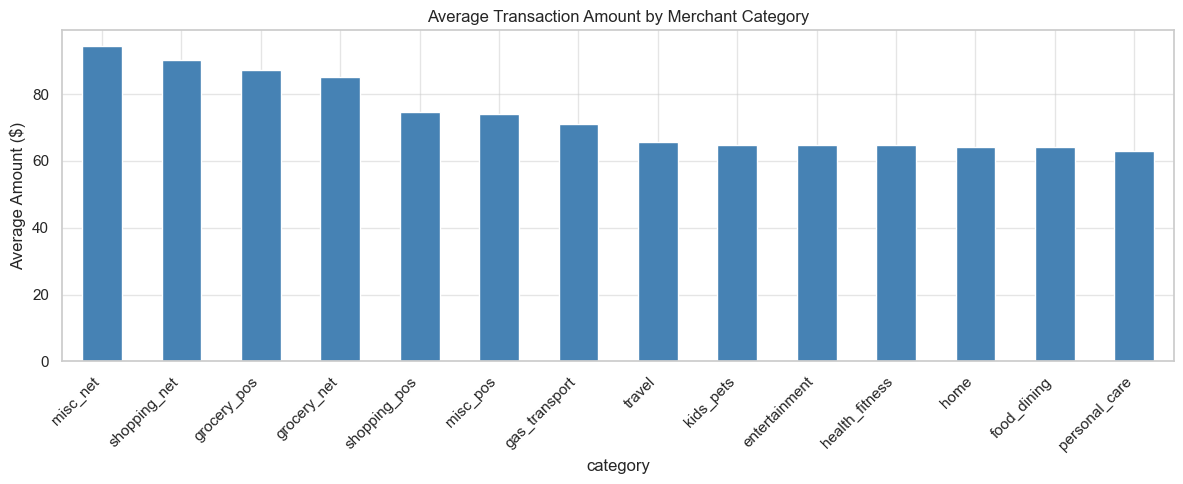

In [31]:
# Average spend per category
df.groupby('category')['amt'].mean().sort_values(ascending=False).plot(
    kind='bar', color='steelblue', edgecolor='white')
plt.title('Average Transaction Amount by Merchant Category')
plt.ylabel('Average Amount ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'avg_spend_per_category.png', bbox_inches='tight', dpi=150)
plt.show()

In [32]:
# Customer average spending window
pio.renderers.default = "notebook_connected"
fig_mpl, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title in zip(axes,
    ['customer_avg_amout_1_day', 'customer_avg_amount_7_day', 'customer_avg_amount_30_day'],
    ['Avg Spend - 1 Day', 'Avg Spend - 7 Days', 'Avg Spend - 30 Days']):

    for flag, color, label in [(0, 'steelblue', 'Legitimate'), (1, 'tomato', 'Fraud')]:
        ax.hist(df[df['is_fraud'] == flag][col], bins=40, alpha=0.6, color=color, label=label, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Amount ($)')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Customer Average Spend Windows', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'customer_average_spend_window.png', bbox_inches='tight', dpi=150)
plt.close()

# ── interactive plotly version ────────────────────────────────────────
columns = [
    ('customer_num_trans_1_day',  'Txns — Last 1 Day'),
    ('customer_num_trans_7_day',  'Txns — Last 7 Days'),
    ('customer_num_trans_30_day', 'Txns — Last 30 Days'),
]

fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=[c[1] for c in columns]
)

for i, (col, title) in enumerate(columns, start=1):

    bins = np.linspace(
        df[col].min(),
        df[col].max(),
        31
    )

    for flag, color, label in [
        (0, 'rgba(37, 99, 235, 0.55)', 'Legitimate'),
        (1, 'rgba(220, 38, 38, 0.55)', 'Fraud'),
    ]:

        values = df[df['is_fraud'] == flag][col].dropna()

        counts, edges = np.histogram(values, bins=bins)

        fig.add_trace(

            go.Bar(
                x=edges[:-1],
                y=counts,
                width=np.diff(edges),

                name=label,

                marker_color=color,
                marker_line_color=color.replace('0.55', '1.0'),
                marker_line_width=0.5,

                legendgroup=label,
                showlegend=(i == 1),

                hovertemplate=
                f"<b>{label}</b>"
                "<br>Transactions: %{x:.0f}"
                "<br>Count: %{y}"
                "<extra></extra>",
            ),

            row=1,
            col=i
        )

# ── Layout ──────────────────────────────────────────────────
fig.update_layout(

    title=dict(
        text='Customer Transaction Frequency Windows',
        font=dict(size=16)
    ),
    template='plotly_white',
    barmode='overlay',
    bargap=0,
    bargroupgap=0.05,
    height=450,
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.08,
        xanchor='center',
        x=0.5,
        itemclick='toggle',
        itemdoubleclick='toggleothers',
    )
)

fig.update_xaxes(title_text='# Transactions')
fig.update_yaxes(title_text='Count', col=1)

clear_output(wait=True)

fig.show()

# 5. Transaction Frequency Analysis

In [33]:
# Transactions by hour of day
pio.renderers.default = "notebook_connected"
hourly = df.groupby(['trans_time_hrs', 'is_fraud']).size().unstack(fill_value=0)
hourly.columns = ['Legitimate', 'Fraud']

# ── save PNG with matplotlib ──────────────────────────────────────────
hourly.plot(kind='bar', figsize=(14, 5), color=['steelblue', 'tomato'],
            edgecolor='white', width=0.8)
plt.title('Transactions by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'transactions_by_hour_of_day.png', bbox_inches='tight', dpi=150)
plt.close()

# ── interactive display with plotly ──────────────────────────────────
fig = go.Figure()

fig.add_trace(go.Bar(
    x=hourly.index,
    y=hourly['Legitimate'],
    name='Legitimate',
    marker_color='rgba(37, 99, 235, 0.6)',
    marker_line_color='rgba(37, 99, 235, 1.0)',
    marker_line_width=0.5,
    hovertemplate='<b>Legitimate</b><br>Hour: %{x}:00<br>Count: %{y}<extra></extra>',
))

fig.add_trace(go.Bar(
    x=hourly.index,
    y=hourly['Fraud'],
    name='Fraud',
    marker_color='rgba(220, 38, 38, 0.6)',
    marker_line_color='rgba(220, 38, 38, 1.0)',
    marker_line_width=0.5,
    hovertemplate='<b>Fraud</b><br>Hour: %{x}:00<br>Count: %{y}<extra></extra>',
))

fig.update_layout(
    title=dict(text='Transactions by hour of day', font=dict(size=15)),
    xaxis=dict(
        title='Hour',
        tickmode='array',
        tickvals=list(range(24)),
        ticktext=[str(h) for h in range(24)],
    ),
    yaxis=dict(title='Count'),
    barmode='group',
    bargap=0.15,
    bargroupgap=0.05,
    legend=dict(
        orientation='h',
        yanchor='bottom', y=1.05,
        xanchor='center', x=0.5,
        itemclick='toggle',
        itemdoubleclick='toggleothers',
    ),
    height=420,
    template='plotly_white',
)

clear_output(wait=True)
fig.show()

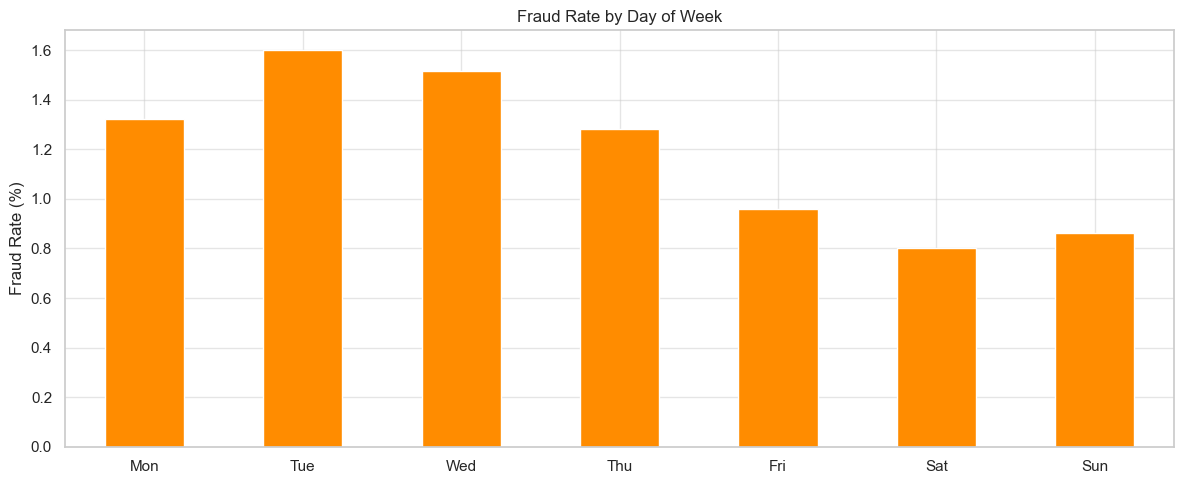

In [34]:
# Fraud rate by day of week
day_fraud = df.groupby('trans_time_day')['is_fraud'].mean() * 100
day_fraud.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day_fraud.plot(kind='bar', color='darkorange', edgecolor='white')
plt.title('Fraud Rate by Day of Week')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fraud_rate_by_day_of_week.png', bbox_inches='tight', dpi=150)
plt.show()

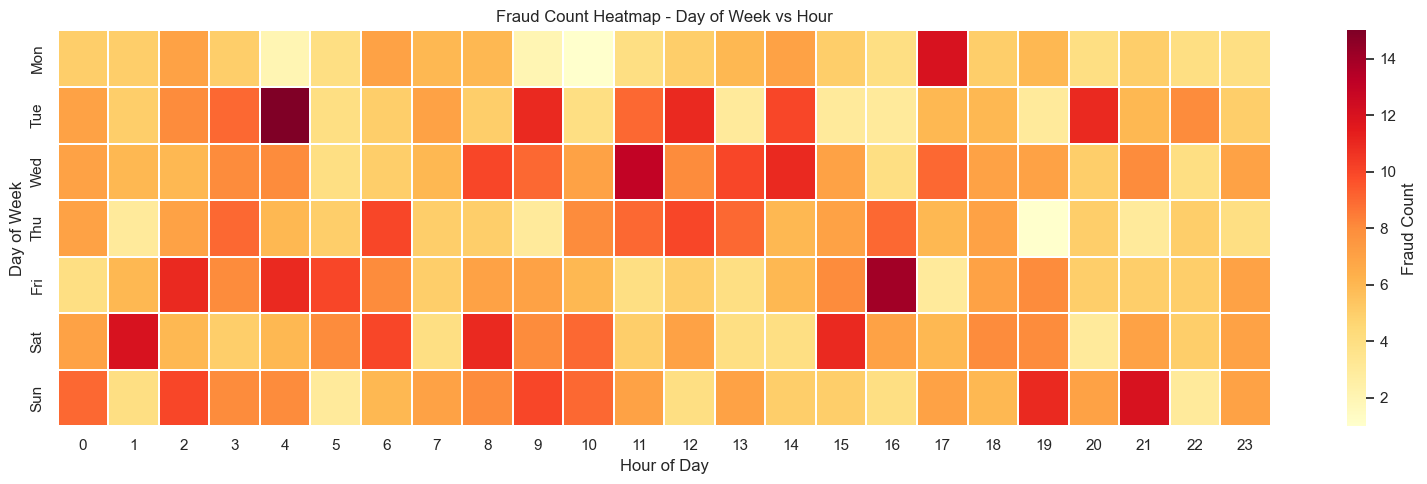

In [35]:
# Heatmap: Day of week vs Hour (fraud transactions only)
pivot = df[df['is_fraud'] == 1].groupby(['trans_time_day', 'trans_time_hrs']).size().unstack(fill_value=0)
pivot.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

plt.figure(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, cbar_kws={'label': 'Fraud Count'})
plt.title('Fraud Count Heatmap - Day of Week vs Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'heatmap_days_of_week_vs_hour.png', bbox_inches='tight', dpi=150)
plt.show()

In [36]:
# Customer Transaction frequency window
pio.renderers.default = "notebook_connected"
fig_mpl, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title in zip(axes,
    ['customer_num_trans_1_day', 'customer_num_trans_7_day', 'customer_num_trans_30_day'],
    ['Txns - Last 1 Day', 'Txns - Last 7 Days', 'Txns - Last 30 Days']):

    for flag, color, label in [(0, 'steelblue', 'Legitimate'), (1, 'tomato', 'Fraud')]:
        ax.hist(df[df['is_fraud'] == flag][col], bins=30, alpha=0.6, color=color, label=label, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('# Transactions')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Customer Transaction Frequency Windows', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'customer_transaction_count.png', bbox_inches='tight', dpi=150)
plt.close()

# ── interactive plotly version ────────────────────────────────────────
columns = [
    ('customer_num_trans_1_day',  'Txns — Last 1 day'),
    ('customer_num_trans_7_day',  'Txns — Last 7 days'),
    ('customer_num_trans_30_day', 'Txns — Last 30 days'),
]

fig = make_subplots(rows=1, cols=3, subplot_titles=[c[1] for c in columns])

for i, (col, title) in enumerate(columns, start=1):
    bins = np.linspace(df[col].min(), df[col].max(), 31)

    for flag, color, label in [
        (0, 'rgba(37, 99, 235, 0.5)',  'Legitimate'),
        (1, 'rgba(220, 38, 38, 0.5)',  'Fraud'),
    ]:
        values = df[df['is_fraud'] == flag][col].dropna()
        counts, edges = np.histogram(values, bins=bins)

        fig.add_trace(
            go.Bar(
                x=edges[:-1],
                y=counts,
                width=np.diff(edges),
                name=label,
                marker_color=color,
                marker_line_color=color.replace('0.5', '1.0'),
                marker_line_width=0.5,
                legendgroup=label,
                showlegend=(i == 1),
                hovertemplate=f"<b>{label}</b><br>Txns: %{{x:.0f}}<br>Count: %{{y}}<extra></extra>",
            ),
            row=1, col=i,
        )

fig.update_layout(
    title=dict(text='Customer transaction frequency windows', font=dict(size=15)),
    barmode='overlay',
    bargap=0,
    legend=dict(
        orientation='h',
        yanchor='bottom', y=1.08,
        xanchor='center', x=0.5,
        itemclick='toggle',
        itemdoubleclick='toggleothers',
    ),
    height=420,
    template='plotly_white',
)

fig.update_xaxes(title_text='# Transactions')
fig.update_yaxes(title_text='Count', col=1)

clear_output(wait=True)
fig.show()

In [37]:
# Mean transaction counts by window for fraud vs legit
freq_cols = ['customer_num_trans_1_day', 'customer_num_trans_7_day', 'customer_num_trans_30_day']
df.groupby('is_fraud')[freq_cols].mean().T.rename(columns={0:'Legitimate', 1:'Fraud'})

is_fraud,Legitimate,Fraud
customer_num_trans_1_day,3.004692,3.071235
customer_num_trans_7_day,5.491865,5.529306
customer_num_trans_30_day,12.989190,12.940487


# 6. Location Based Analysis

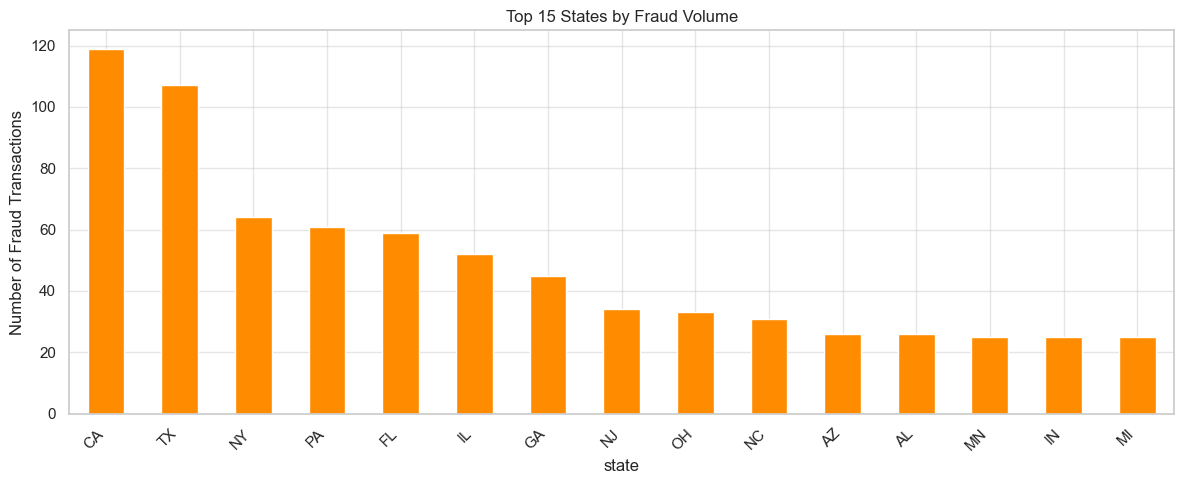

In [38]:
# Total fraud volume by state
df[df['is_fraud'] == 1]['state'].value_counts().head(15).plot(
    kind='bar', color='darkorange', edgecolor='white')
plt.title('Top 15 States by Fraud Volume')
plt.ylabel('Number of Fraud Transactions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'total_fraud_volume_by_state', bbox_inches='tight', dpi=150)
plt.show()

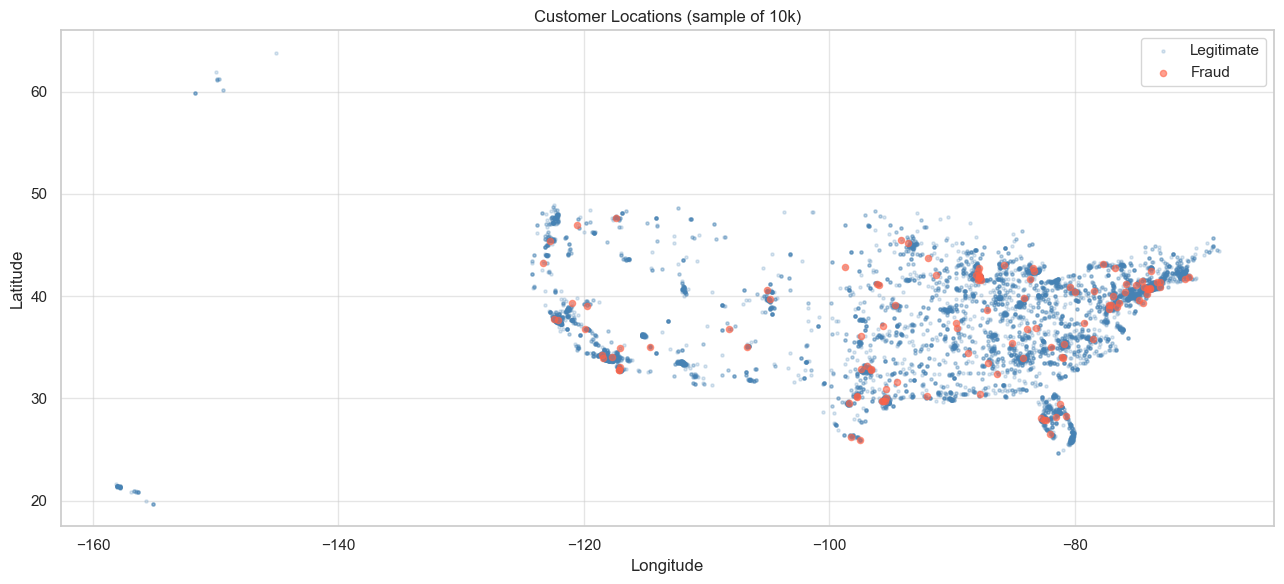

In [39]:
# Customer location scatter - colored by fraud
sample = df.sample(n=min(10000, len(df)), random_state=42)
plt.figure(figsize=(13, 6))
plt.scatter(sample[sample['is_fraud']==0]['long'], sample[sample['is_fraud']==0]['lat'],
            alpha=0.2, s=5, color='steelblue', label='Legitimate')
plt.scatter(sample[sample['is_fraud']==1]['long'], sample[sample['is_fraud']==1]['lat'],
            alpha=0.6, s=20, color='tomato', label='Fraud')
plt.title('Customer Locations (sample of 10k)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'customer_location_scatter.png', bbox_inches='tight', dpi=150)
plt.show()

In [40]:
# Distance between customer and merchant
from math import asin, cos, radians, sin, sqrt


def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    a = sin((lat2-lat1)/2)**2 + cos(lat1)*cos(lat2)*sin((lon2-lon1)/2)**2
    return 2 * R * asin(sqrt(a))

df['cust_merch_distance_km'] = df.apply(
    lambda r: haversine(r['lat'], r['long'], r['merch_lat'], r['merch_long']), axis=1)

df.groupby('is_fraud')['cust_merch_distance_km'].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,98891.0,76.510484,29.239390,0.307495,55.864624,78.666506,98.891158,147.624180
1,1109.0,76.270529,28.944497,4.511647,54.515767,78.114026,99.438839,144.210978


# 8. Customer Demographics

In [41]:
pio.renderers.default = "notebook_connected"

df['dob'] = pd.to_datetime(df['dob'])
df['age'] = (pd.Timestamp.today() - df['dob']).dt.days // 365

fig_mpl, ax = plt.subplots(figsize=(12, 5))
for flag, color, label in [(0, 'steelblue', 'Legitimate'), (1, 'tomato', 'Fraud')]:
    ax.hist(df[df['is_fraud'] == flag]['age'], bins=30, alpha=0.6, color=color, label=label, edgecolor='white')
ax.set_title('Customer Age Distribution by Class')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cutomer_age_distribution_by_class.png', bbox_inches='tight', dpi=150)
plt.close()

# ── interactive plotly version ────────────────────────────────────────
bins = np.linspace(df['age'].min(), df['age'].max(), 31)

fig = go.Figure()

for flag, color, label in [
    (0, 'rgba(37, 99, 235, 0.5)', 'Legitimate'),
    (1, 'rgba(220, 38, 38, 0.5)', 'Fraud'),
]:
    values = df[df['is_fraud'] == flag]['age'].dropna()
    counts, edges = np.histogram(values, bins=bins)

    fig.add_trace(go.Bar(
        x=edges[:-1],
        y=counts,
        width=np.diff(edges),
        name=label,
        marker_color=color,
        marker_line_color=color.replace('0.5', '1.0'),
        marker_line_width=0.5,
        hovertemplate=f"<b>{label}</b><br>Age: %{{x:.0f}}<br>Count: %{{y}}<extra></extra>",
    ))

fig.update_layout(
    title=dict(text='Customer age distribution by class', font=dict(size=15)),
    xaxis=dict(title='Age'),
    yaxis=dict(title='Count'),
    barmode='overlay',
    bargap=0,
    legend=dict(
        orientation='h',
        yanchor='bottom', y=1.05,
        xanchor='center', x=0.5,
        itemclick='toggle',
        itemdoubleclick='toggleothers',
    ),
    height=420,
    template='plotly_white',
)
clear_output(wait=True)
fig.show()

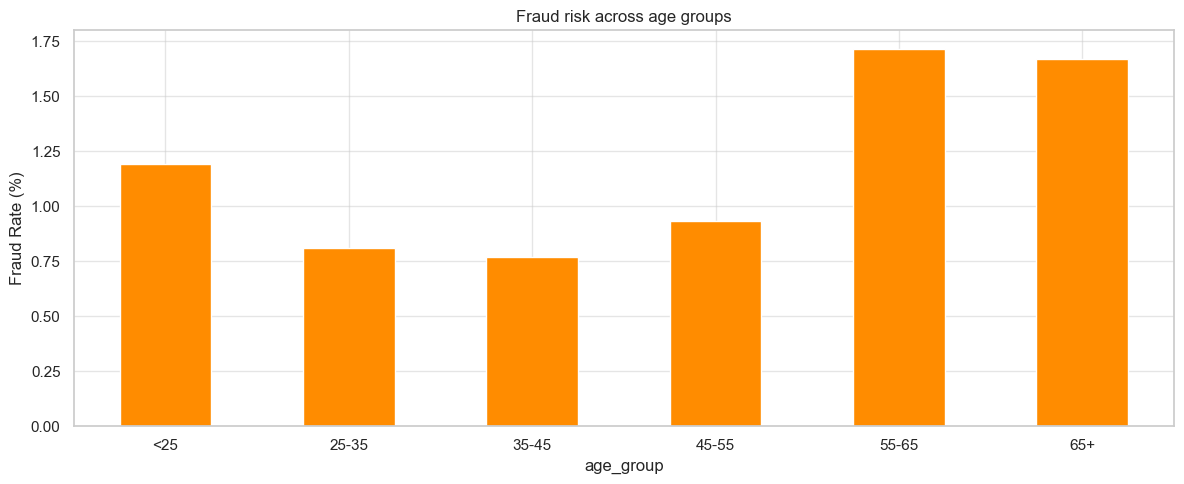

In [42]:
# Fraud rate by age group
df['age_group'] = pd.cut(df['age'], bins=[0,25,35,45,55,65,100],
                          labels=['<25','25-35','35-45','45-55','55-65','65+'])
df.groupby('age_group', observed = True)['is_fraud'].mean().mul(100).plot(
    kind='bar', color='darkorange', edgecolor='white')
plt.title('Fraud risk across age groups')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fraud_risk_across_age_groups.png', bbox_inches='tight', dpi=150)
plt.show()

# 8. Correlation and Feature Realtionships

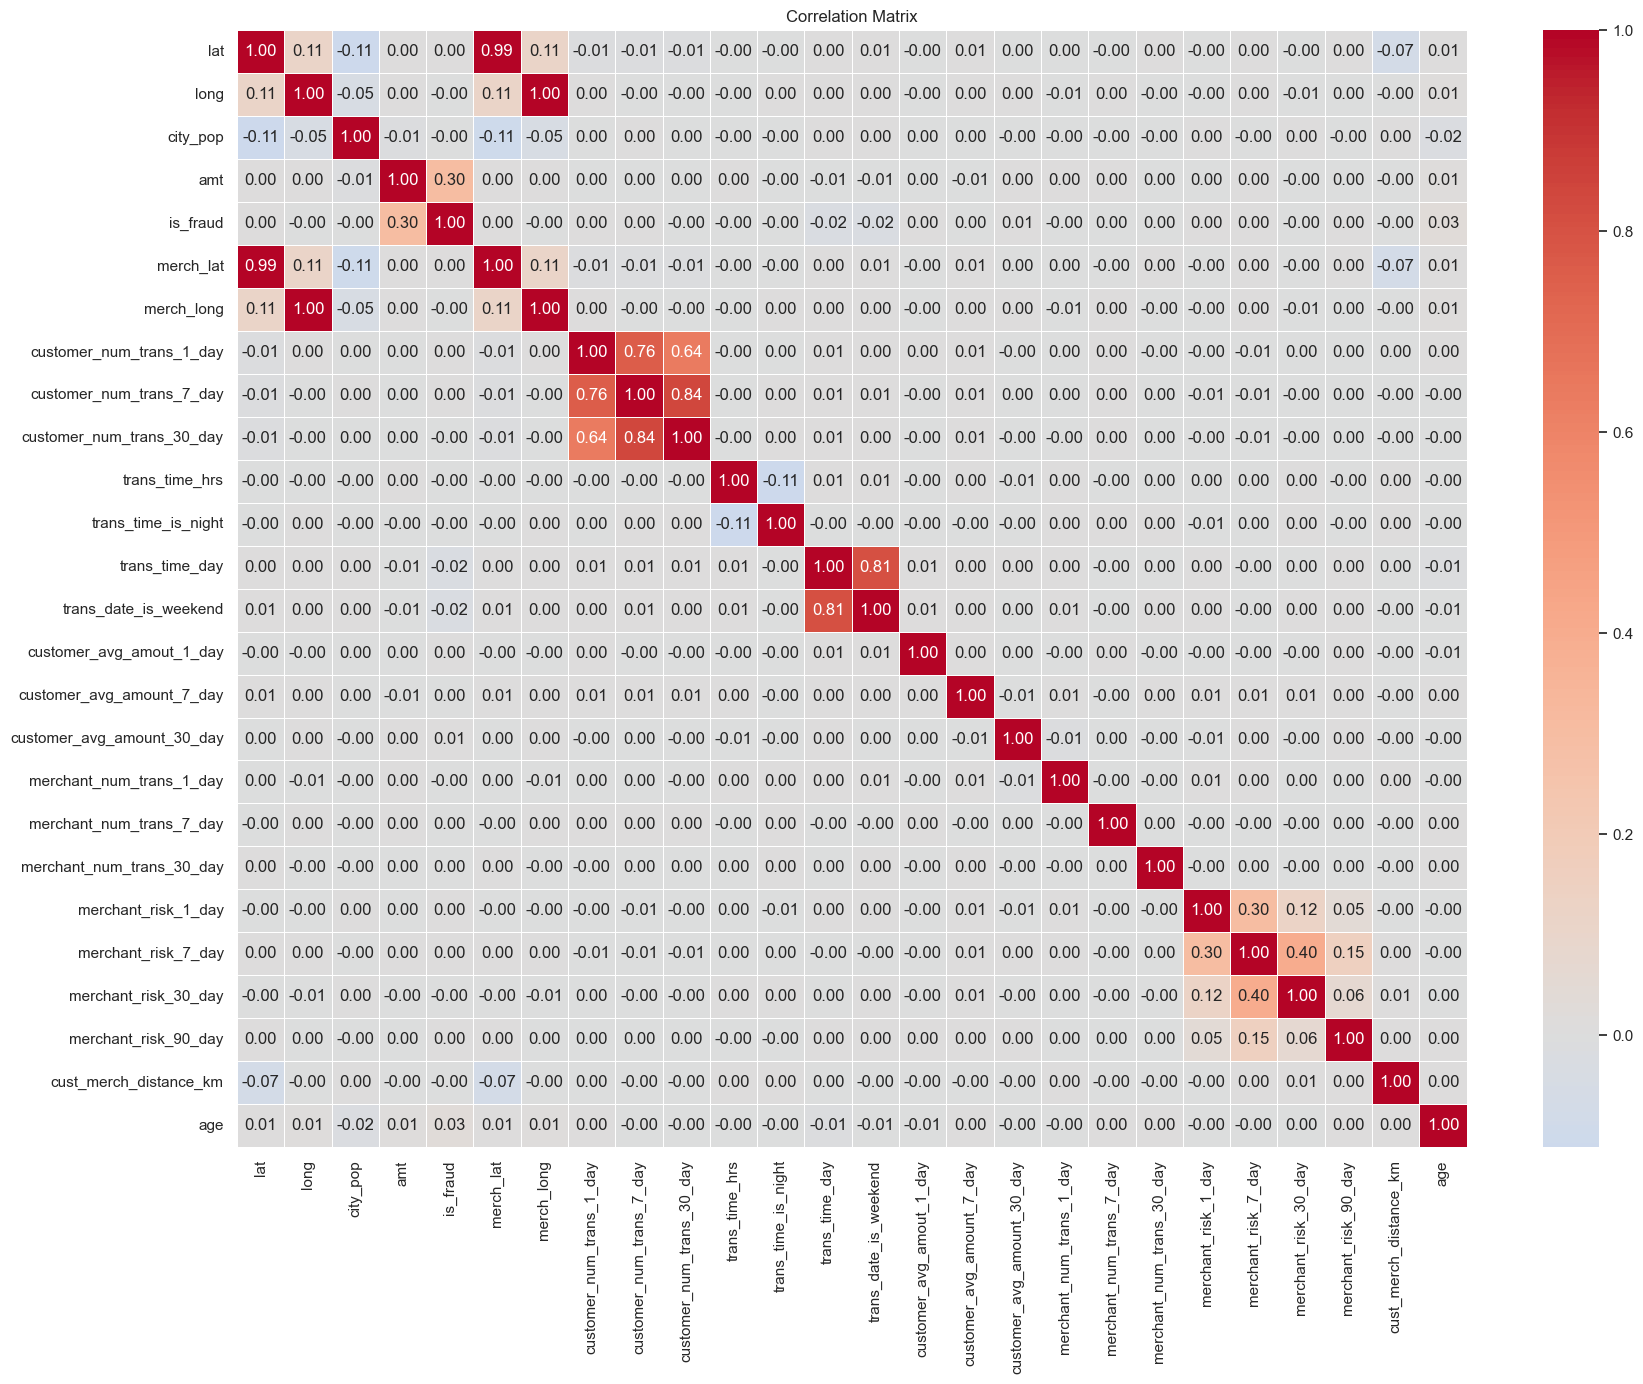

In [43]:
# Drop identifier columns before correlation
drop_cols = ['cc_num', 'acct_num', 'unix_time', 'zip', 'trans_time_secs']
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=drop_cols, errors='ignore')

corr = numeric_df.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.4)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

In [44]:
# Features most correlated with is_fraud
corr_with_fraud = numeric_df.corr()['is_fraud'].drop('is_fraud').sort_values(key=abs, ascending=False)
print('Features most correlated with fraud:\n')
print(corr_with_fraud)

Features most correlated with fraud:

amt                           0.302957
age                           0.029414
trans_time_day               -0.024776
trans_date_is_weekend        -0.021794
customer_avg_amount_30_day    0.005583
trans_time_hrs               -0.004985
city_pop                     -0.003579
customer_num_trans_1_day      0.003484
merchant_risk_30_day         -0.002856
merchant_risk_7_day           0.002609
lat                           0.002503
merchant_risk_90_day          0.002394
long                         -0.002265
merch_long                   -0.002244
trans_time_is_night          -0.001993
merch_lat                     0.001869
merchant_risk_1_day           0.001691
customer_num_trans_30_day    -0.001629
customer_num_trans_7_day      0.001487
customer_avg_amout_1_day      0.001457
merchant_num_trans_30_day     0.001359
customer_avg_amount_7_day     0.001345
merchant_num_trans_7_day      0.001122
cust_merch_distance_km       -0.000860
merchant_num_trans_1_day  